## Setup

In [51]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

REPORTS_DIR = Path.cwd() / "reports"

## Load Reports

In [52]:
def load_reports(report_dir):
    reports = {}
    for p in report_dir.glob("*_build_status.json"):
        repo = p.stem.replace("_build_status", "")
        with p.open() as f: raw = json.load(f)
        reports[repo] = raw["report"]
    return reports

reports = load_reports(REPORTS_DIR)
print("repos:", len(reports))

repos: 10


## Convert to DataFrames

In [70]:
def flatten_totals(reports):
    rows = []
    for repo, row in reports.items():
        report = row if "totals" in row else row["report"]
        section_labels = report["labels"]["sections"]
        field_labels = report["labels"]["fields"]
        for section, metrics in report["totals"].items():
            section_label = section_labels[section]
            for metric, value in metrics.items():
                metric_label = field_labels[metric]
                rows.append({
                    "repo": repo,
                    "section": section_label,
                    "metric": metric_label,
                    "value": value
                })
        section_timing = "Timing"
        report = row if "timing" in row else row["report"]
        phase_labels = report["labels"]["phases"]
        rows.append({
            "repo": repo,
            "section": section_timing,
            "metric": field_labels["build_total_seconds"],
            "value": report["timing"]["build_total_seconds"]
        })
        rows.append({
            "repo": repo,
            "section": section_timing,
            "metric": field_labels["build_wall_seconds"],
            "value": report["timing"]["build_wall_seconds"]
        })
        for phase, time in report["timing"]["build_phase_timings"].items():
            rows.append({
                "repo": repo,
                "section": section_timing,
                "metric": phase_labels[phase],
                "value": time
            })

    return pd.DataFrame(rows)

totals_df= flatten_totals(reports)

In [55]:
def flatten_scopes(reports):
    rows = []
    for repo, row in reports.items():
        report = row if "scopes" in row else row["report"]
        section_labels = report["labels"]["sections"]
        field_labels = report["labels"]["fields"]
        scope_labels = report["labels"]["scopes"]
        for scope, sections in report["scopes"].items():
            scope_label = scope_labels[scope]
            for section, metrics in sections.items():
                section_label = section_labels[section]
                for metric, value in metrics.items():
                    metric_label = field_labels[metric]
                    rows.append({
                        "repo": repo,
                        "scope": scope_label,
                        "section": section_label,
                        "metric": metric_label,
                        "value": value
                    })

    return pd.DataFrame(rows)

scopes_df= flatten_scopes(reports)

In [56]:
def flatten_languages(reports):
    rows = []
    for repo, row in reports.items():
        report = row if "languages" in row else row["report"]
        section_labels = report["labels"]["sections"]
        field_labels = report["labels"]["fields"]
        for language, sections in report["languages"].items():
            language_label = language
            for section, metrics in sections.items():
                section_label = section_labels[section]
                for metric, value in metrics.items():
                    metric_label = field_labels[metric]
                    rows.append({
                        "repo": repo,
                        "language": language_label,
                        "section": section_label,
                        "metric": metric_label,
                        "value": value
                    })

    return pd.DataFrame(rows)

languages_df= flatten_languages(reports)

## Repository breakdown

In [71]:
totals_pivot = totals_df.pivot(
    index="repo",
    columns=["section","metric"],
    values="value")
totals_pivot

section      Structure                                        Callsites  \
metric           Files     Nodes     Edges Observed Syntactic Callsites   
repo                                                                      
airbyte         3288.0   25275.0   38063.0                      15626.0   
axios            173.0     576.0     805.0                        231.0   
commons-lang     534.0   11566.0   17316.0                       5692.0   
fastapi         1287.0    6604.0    7754.0                       2310.0   
guava           3245.0   64131.0  103276.0                      36639.0   
nest            1708.0    6416.0   10200.0                       2353.0   
pydantic         407.0   13301.0   16283.0                       3263.0   
sympy           1590.0   40980.0   99191.0                      72663.0   
vscode          6765.0  108097.0  346645.0                     155451.0   
webpack         8703.0   14945.0   14428.0                       3368.0   

section                                                                   \
metric       Filtered Pre-Persist Persisted Callsites Persisted Accepted   
repo                                                                       
airbyte                     896.0             14730.0            14441.0   
axios                        66.0               165.0              161.0   
commons-lang                205.0              5487.0             5376.0   
fastapi                    1078.0              1232.0              716.0   
guava                      1266.0             35373.0            34844.0   
nest                        342.0              2011.0             1952.0   
pydantic                    848.0              2415.0             2273.0   
sympy                     25344.0             47319.0            47109.0   
vscode                    10208.0            145243.0           141486.0   
webpack                     156.0              3212.0             3135.0   

section                          Pre-Persist Filter                           \
metric       Persisted Dropped No In-Repo Candidate Accepted Outside In-Repo   
repo                                                                           
airbyte                  289.0                896.0                      0.0   
axios                      4.0                 66.0                      0.0   
commons-lang             111.0                205.0                      0.0   
fastapi                  516.0               1078.0                      0.0   
guava                    529.0               1266.0                      0.0   
nest                      59.0                342.0                      0.0   
pydantic                 142.0                848.0                      0.0   
sympy                    210.0              25344.0                      0.0   
vscode                  3757.0              10208.0                      0.0   
webpack                   77.0                156.0                      0.0   

section       ...                 Timing                            \
metric        ... Build Structural Index Compute Build Fingerprint   
repo          ...                                                    
airbyte       ...              21.373260                  0.851458   
axios         ...               0.777111                  0.204074   
commons-lang  ...               6.489825                  0.368914   
fastapi       ...               3.543903                  0.311912   
guava         ...              34.214596                  0.232071   
nest          ...               4.808468                  0.294468   
pydantic      ...               7.231047                  0.233756   
sympy         ...              38.140406                  0.517625   
vscode        ...             139.329995                  1.289805   
webpack       ...              15.693623                  0.391171   

section                                                                       \
met

In [58]:
def plot_totals_section(section):

    subset = totals_df[totals_df.section == section]

    pivot = subset.pivot(
        index="repo",
        columns="metric",
        values="value"
    )

    ax = pivot.plot.bar(figsize=(10,4))
    ax.set_title(section)
    ax.set_ylabel("Value")

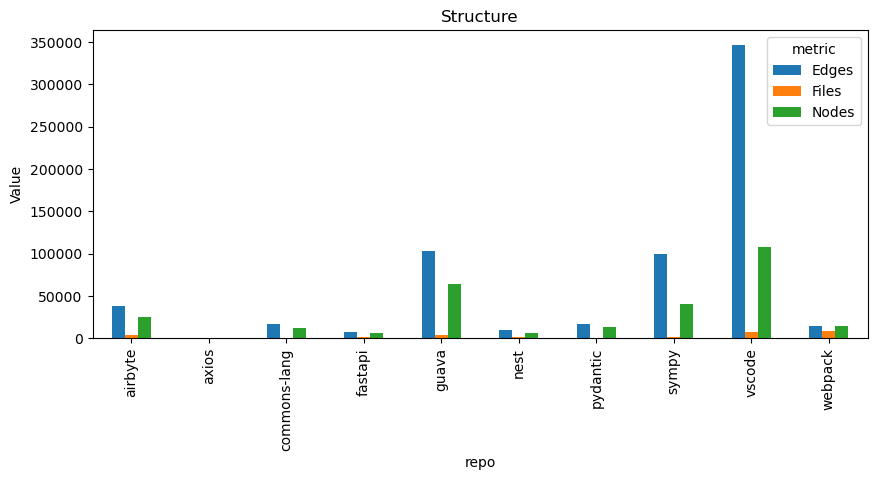

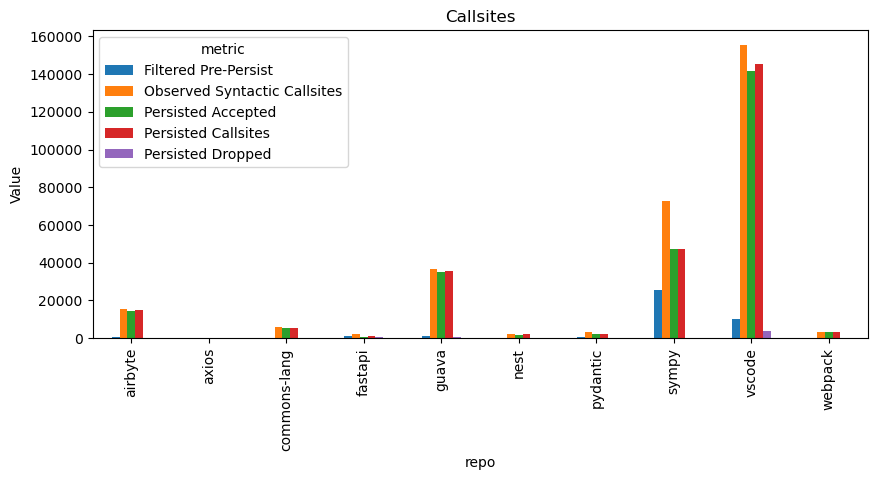

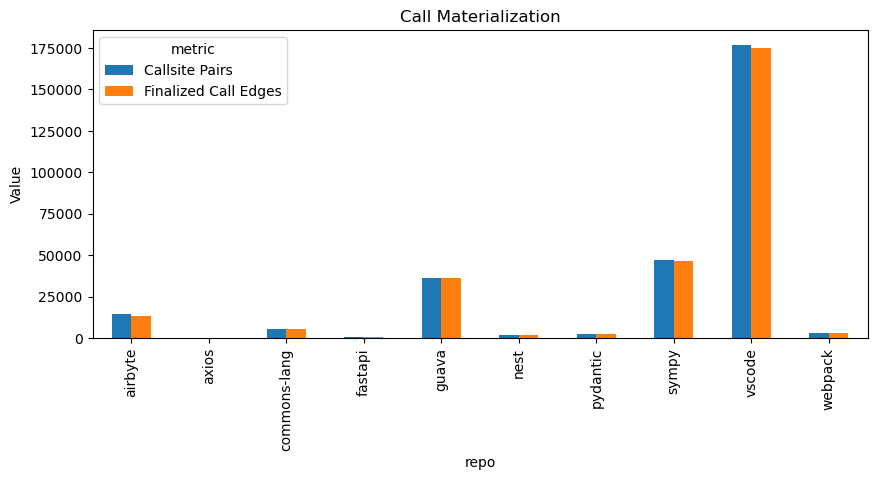

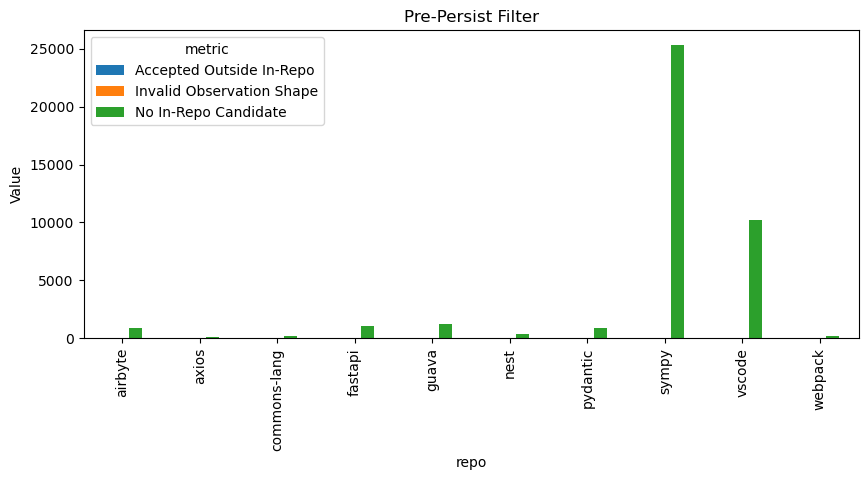

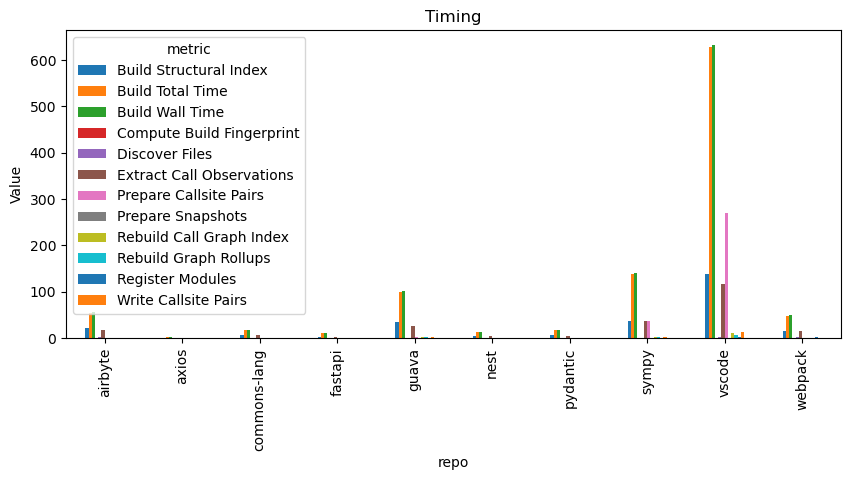

In [72]:
plot_totals_section("Structure")
plot_totals_section("Callsites")
plot_totals_section("Call Materialization")
plot_totals_section("Pre-Persist Filter")
plot_totals_section("Timing")

## Language breakdown

In [60]:
languages_pivot = languages_df.pivot(
    index=["repo","language"],
    columns=["section","metric"],
    values="value")
languages_pivot

section                 Structure                  \
metric                      Files   Nodes   Edges   
repo         language                               
airbyte      java             473    4144    5397   
             javascript        44     147     180   
             python          2768   20976   32478   
             typescript         3       8       8   
axios        javascript       167     438     673   
             typescript         6     138     132   
commons-lang java             534   11566   17316   
fastapi      javascript         3      25      44   
             python          1284    6579    7710   
guava        java            3243   64129  103276   
             javascript         2       2       0   
nest         javascript        49      61      19   
             typescript      1659    6355   10181   
pydantic     javascript         6      16      18   
             python           401   13285   16265   
sympy        python          1590   40980   99191   
vscode       java               1       5       4   
             javascript       105     392     414   
             python             3      14      11   
             typescript      6656  107686  346216   
webpack      javascript      8615   14757   14312   
             typescript        88     188     116   

section                                    Callsites                       \
metric                  Observed Syntactic Callsites Filtered Pre-Persist   
repo         language                                                       
airbyte      java                               1623                   54   
             javascript                           53                    0   
             python                            13948                  842   
             typescript                            2                    0   
axios        javascript                          231                   66   
             typescript                            0                    0   
commons-lang java                               5692                  205   
fastapi      javascript                           22                    0   
             python                             2288                 1078   
guava        java                              36639                 1266   
             javascript                            0                    0   
nest         javascript                            2                    0   
             typescript                         2351                  342   
pydantic     javascript                            8                    0   
             python                             3255                  848   
sympy        python                            72663                25344   
vscode       java                                  0                    0   
             javascript                          125                    1   
             python                                0                    0   
             typescript                       155326                10207   
webpack      javascript                         3356                  156   
             typescript                           12                    0   

section                                                         \
metric                  Persisted Callsites Persisted Accepted   
repo         language                                            
airbyte      java                      1569               1556   
             javascript                  53                 53   
             python                   13106              12830   
             typescript                   2                  2   
axios        javascript                 165                161   
             typescript                   0                  0   
commons-lang java                      5487               5376   
fastapi      javascript                  22                 22   
             python   

In [61]:
def plot_language_metric(section, metric):

    subset = languages_df[
        (languages_df.section == section) &
        (languages_df.metric == metric)
    ]

    pivot = subset.pivot(
        index="repo",
        columns="language",
        values="value"
    )

    pivot.plot.bar(figsize=(10,4))

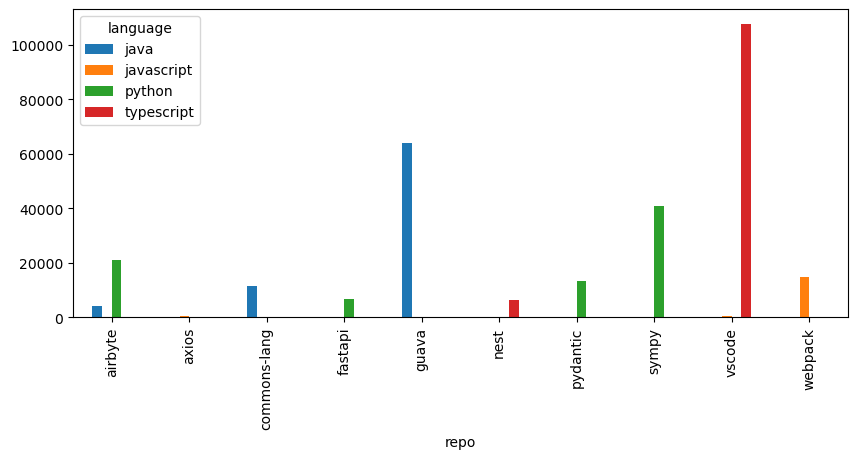

In [62]:
plot_language_metric("Structure", "Nodes")

## Scope breakdown

In [63]:
scopes_pivot = scopes_df.pivot(
    index=["repo","scope"],
    columns=["section","metric"],
    values="value")

scopes_pivot

section                Structure                                   Callsites  \
metric                     Files  Nodes   Edges Observed Syntactic Callsites   
repo         scope                                                             
airbyte      Non-Tests      3098  23583   35939                        15012   
             Tests           190   1692    2124                          614   
axios        Non-Tests        94    449     679                          224   
             Tests            79    127     126                            7   
commons-lang Non-Tests       259   4973    8643                         3403   
             Tests           275   6593    8673                         2289   
fastapi      Non-Tests       721   2457    3059                          739   
             Tests           566   4147    4695                         1571   
guava        Non-Tests      2001  36684   64507                        23556   
             Tests          1244  27447   38769                        13083   
nest         Non-Tests      1479   6033    9313                         2344   
             Tests           229    383     887                            9   
pydantic     Non-Tests       123   2458    4398                         1837   
             Tests           284  10843   11885                         1426   
sympy        Non-Tests       907  26183   54290                        27951   
             Tests           683  14797   44901                        44712   
vscode       Non-Tests      5469  94766  300020                       132767   
             Tests          1296  13331   46625                        22684   
webpack      Non-Tests      1160   5864    9603                         2973   
             Tests          7543   9081    4825                          395   

section                                                          \
metric                 Filtered Pre-Persist Persisted Callsites   
repo         scope                                                
airbyte      Non-Tests                  891               14121   
             Tests                        5                 609   
axios        Non-Tests                   66                 158   
             Tests                        0                   7   
commons-lang Non-Tests                    7                3396   
             Tests                      198                2091   
fastapi      Non-Tests                  279                 460   
             Tests                      799                 772   
guava        Non-Tests                  177               23379   
             Tests                     1089               11994   
nest         Non-Tests                  340                2004   
             Tests                        2                   7   
pydantic     Non-Tests                  300                1537   
             Tests                      548                 878   
sympy        Non-Tests                 5877               22074   
             Tests                    19467               25245   
vscode       Non-Tests                 9697              123070   
             Tests                      511               22173   
webpack      Non-Tests                  151                2822   
             Tests                        5                 390   

section                                                      \
metric                 Persisted Accepted Persisted Dropped   
repo         scope                                            
airbyte      Non-Tests              13836               285   
             Tests                    605                 4   
axios        Non-Tests                154                 4   
             Tests                      7                 0   
commons-lang Non-Tests               3325                71   
             Tests                   2051                40   
fastapi      Non-Tests                453         

In [64]:
def plot_scope_metric(section, metric):

    subset = scopes_df[
        (scopes_df.section == section) &
        (scopes_df.metric == metric)
    ]

    pivot = subset.pivot(
        index="repo",
        columns="scope",
        values="value"
    )

    pivot.plot.bar(figsize=(10,4))

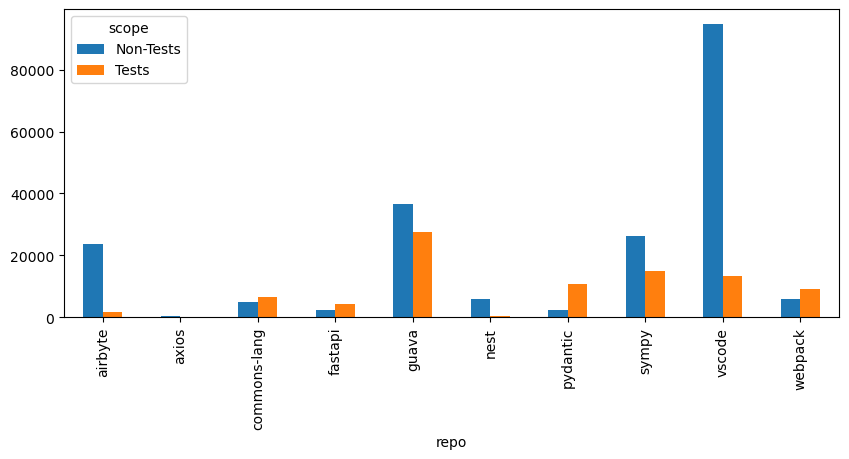

In [68]:
plot_scope_metric("Structure", "Nodes")